In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
options(repr.plot.width=8, repr.plot.height=6, repr.plot.res = 300)
library(showtext)
font_add_google("Lato", "lato")
showtext_opts(dpi = 300)
showtext_auto()

Loading required package: sysfonts

Loading required package: showtextdb



In [3]:
n_girls <- rbinom(1, 400, 0.488)
print(n_girls)

[1] 181


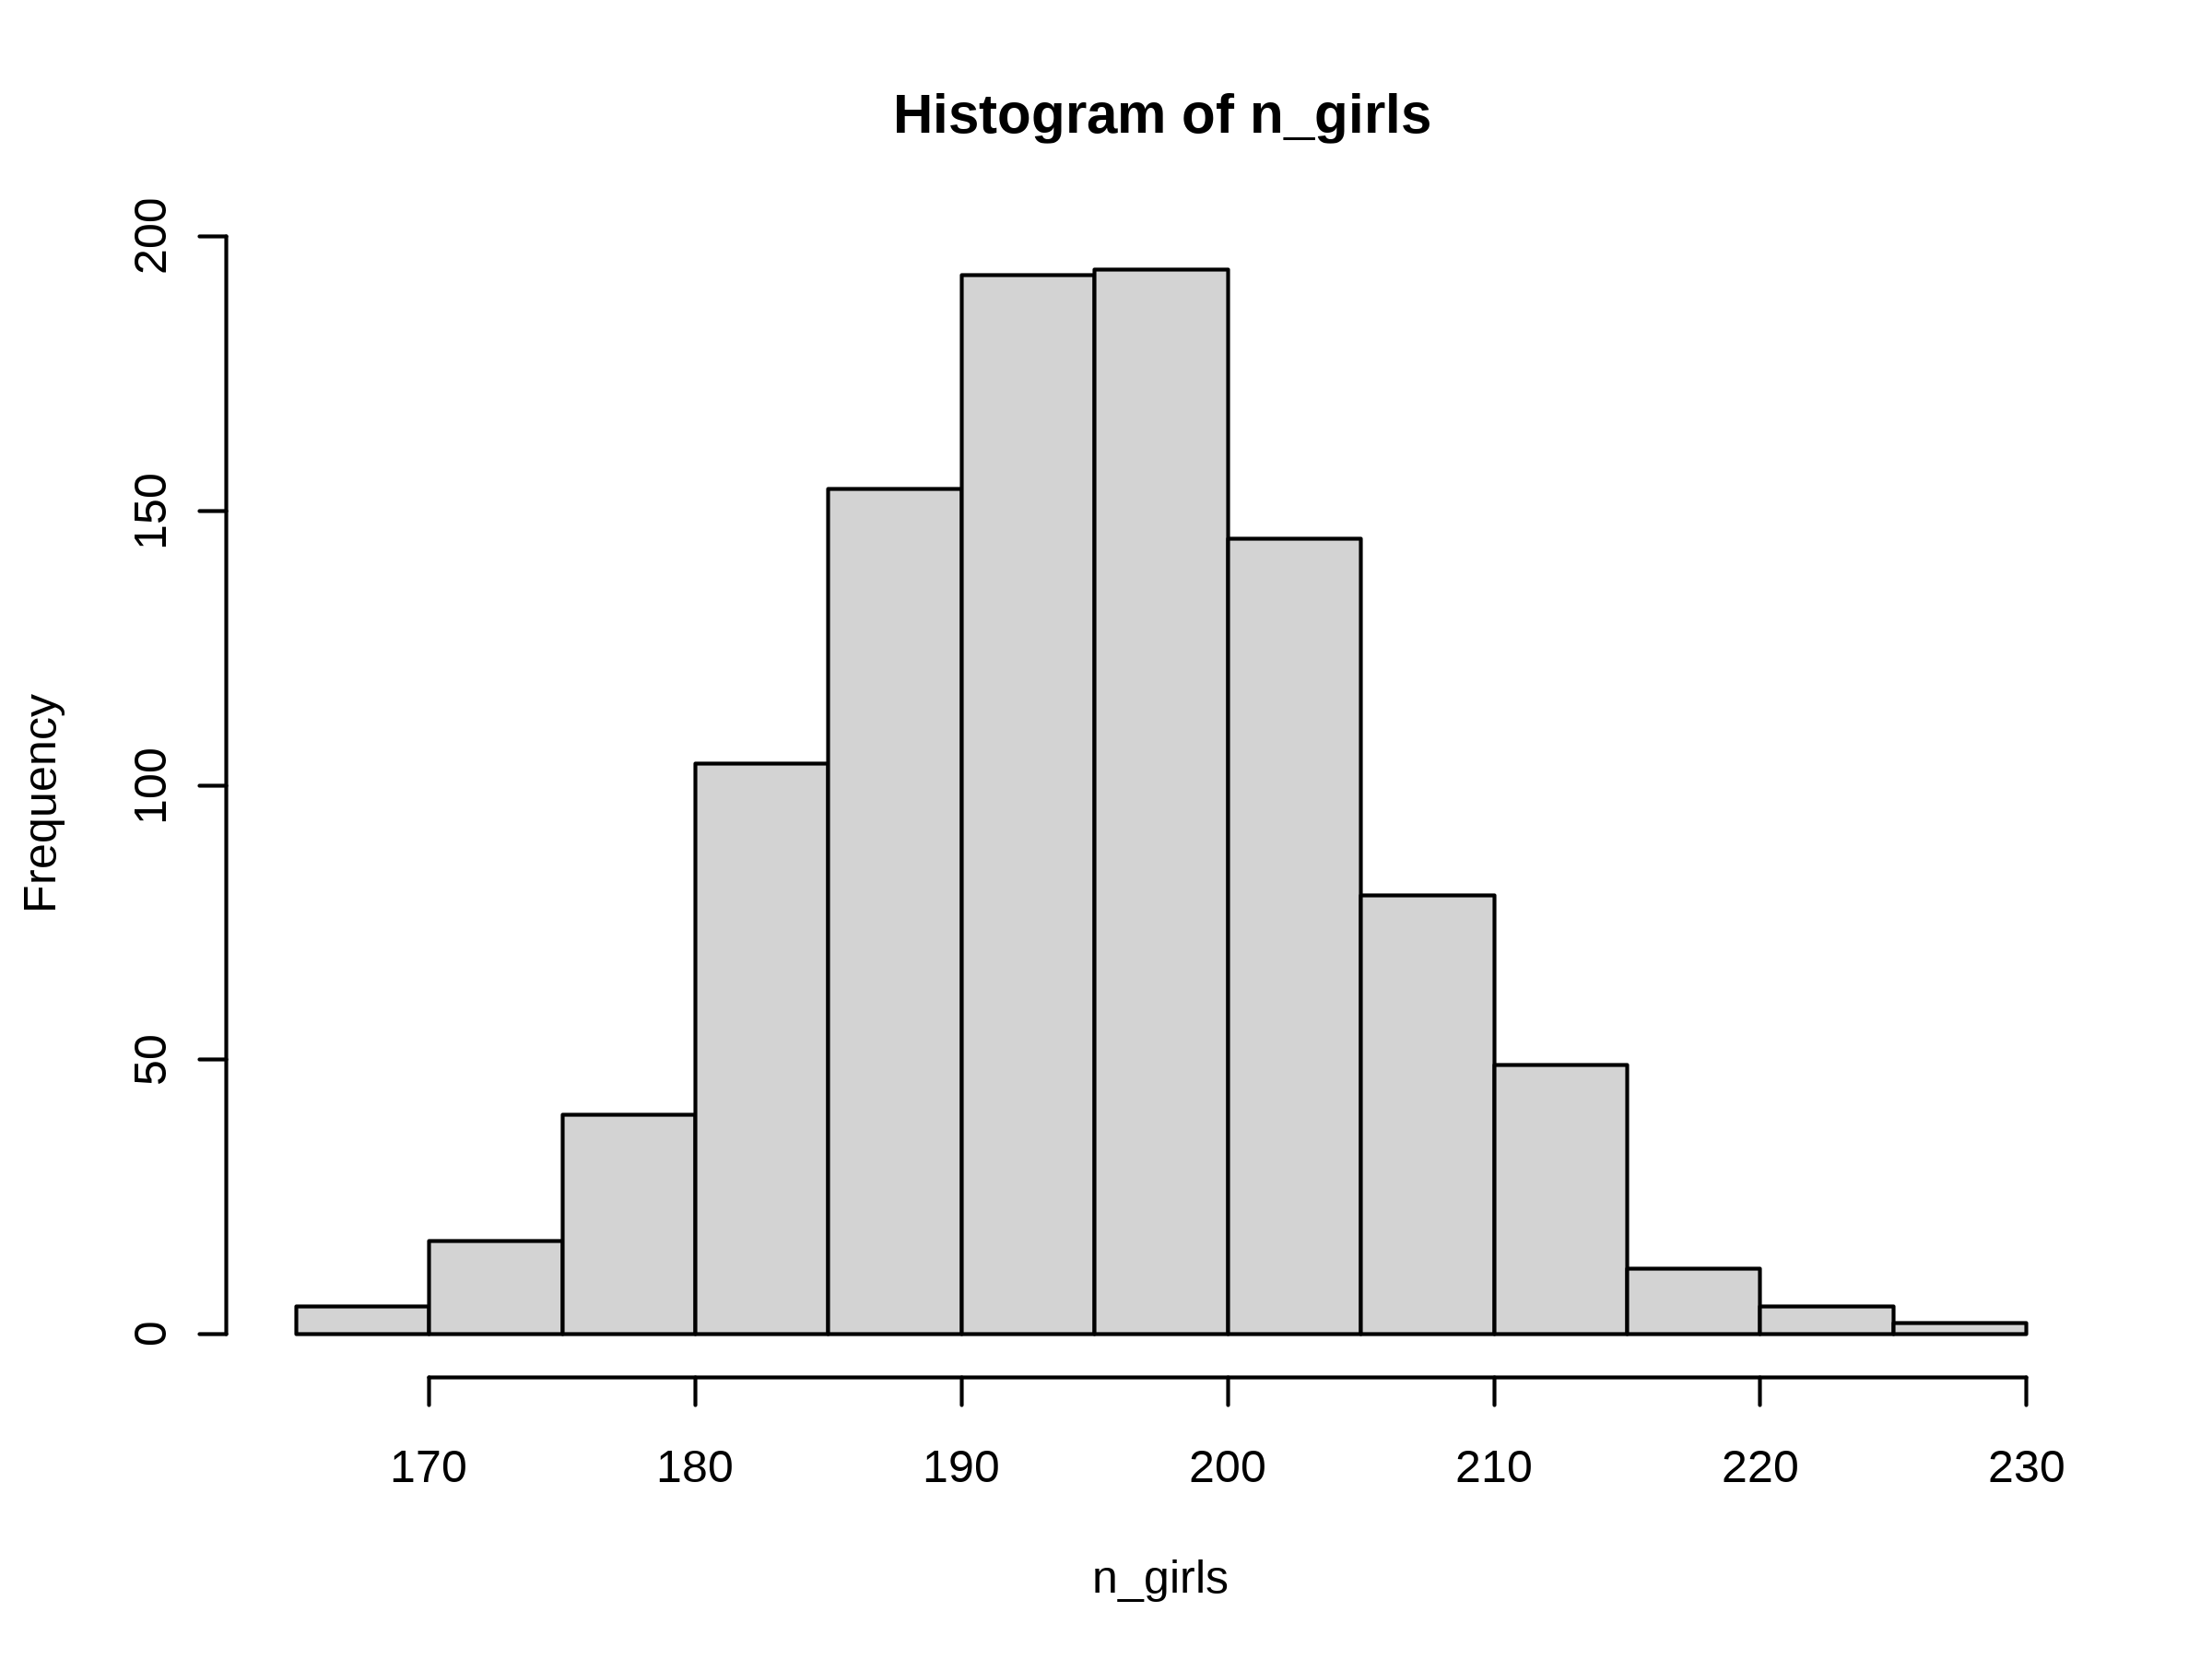

In [7]:
n_sims <- 1000
n_girls <- rbinom(n_sims, 400, 0.488)

hist(n_girls)

In [9]:
birth_type <- sample(
        c("fraternal twin","identical twin","single birth"),
        size=400, replace=TRUE, 
        prob=c(1/125, 1/300, 1 - 1/125 - 1/300)
    )
girls <- rep(NA, 400)
for (i in 1:400){
    if (birth_type[i] == "single birth") {
        girls[i] <- rbinom(1, 1, 0.488)
    } else if (birth_type[i]=="identical twin") {
        girls[i] <- 2*rbinom(1, 1, 0.495)
    } else if (birth_type[i]=="fraternal twin") {
        girls[i] <- rbinom(1, 2, 0.495)
    }
}
n_girls <- sum(girls)

In [11]:
# without for loop
girls <- ifelse(
    birth_type=="single birth", rbinom(400, 1, 0.488),
    ifelse(
        birth_type=="identical twin", 2*rbinom(400, 1, 0.495),
        rbinom(400, 2, 0.495)
    )
)

In [13]:
n_sims <- 1000
n_girls <- rep(NA, n_sims)
for (s in 1:n_sims){
    birth_type <- sample(
        c("fraternal twin","identical twin","single birth"),
        size=400, replace=TRUE, prob=c(1/125, 1/300, 1 - 1/125 - 1/300)
    )
    girls <- ifelse(
        birth_type=="single birth", rbinom(400, 1, 0.488),
        ifelse(
            birth_type=="identical twin", 2*rbinom(400, 1, 0.495),
            rbinom(400, 2, 0.495)
        )
    )
    n_girls[s] <- sum(girls)
}

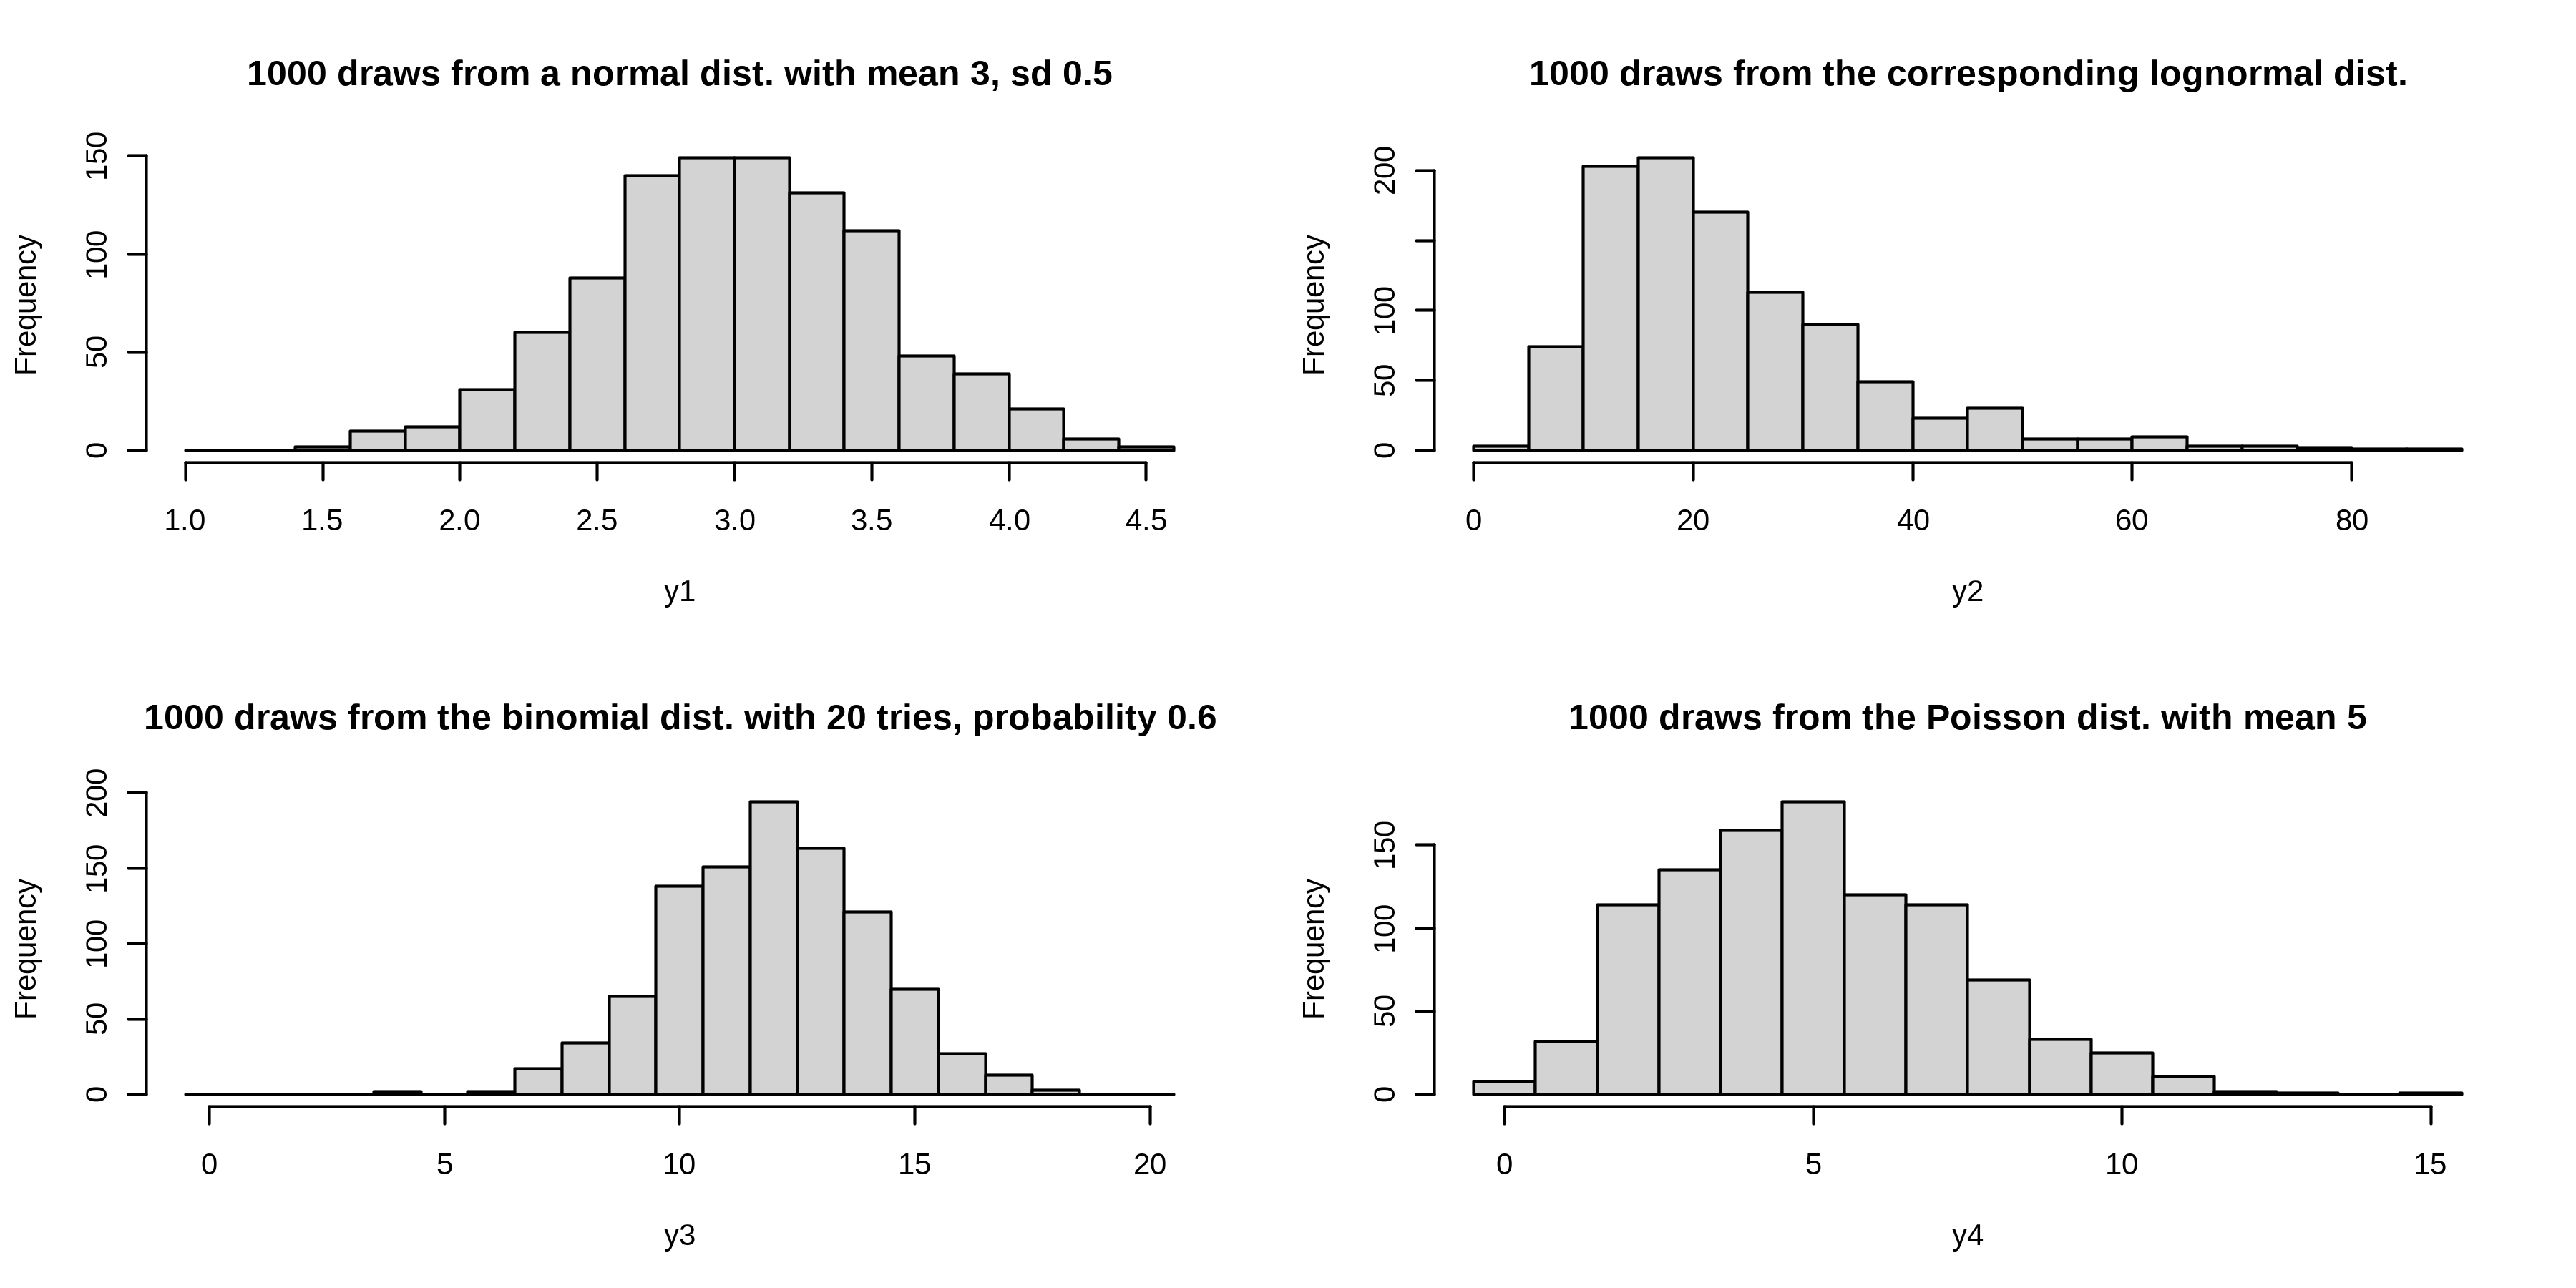

In [20]:
options(repr.plot.width=12, repr.plot.height=6, repr.plot.res = 300)
n_sims <- 1000
y1 <- rnorm(n_sims, 3, 0.5)
y2 <- exp(y1)
y3 <- rbinom(n_sims, 20, 0.6)
y4 <- rpois(n_sims, 5)
par(mfrow=c(2,2))
hist(y1, breaks=seq(floor(min(y1)), max(y1) + 0.2, 0.2),
    main="1000 draws from a normal dist. with mean 3, sd 0.5")
hist(y2, breaks=seq(0, max(y2) + 5, 5),
    main="1000 draws from the corresponding lognormal dist.")
hist(y3, breaks=seq(-0.5, 20.5, 1),
    main="1000 draws from the binomial dist. with 20 tries, probability 0.6")
hist(y4, breaks=seq(-0.5, max(y4) + 1, 1),
    main="1000 draws from the Poisson dist. with mean 5")
options(repr.plot.width=8, repr.plot.height=6, repr.plot.res = 300)